# EDA template — Delhi Phase 1 master feature table

General-purpose EDA notebook, structured as 7 phases that apply to any tabular
dataset. Some phases (e.g. the grouping/time/space checks in Phase 7) only
make sense because *this* dataset has station groups, dates, and lat/lon --
for a dataset without those, you'd just skip that particular sub-check.

To reuse this notebook for a different dataset: edit only the **Config** cell
below (paths + column lists), the rest of the notebook runs unchanged.

## 0. Setup & config

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

In [2]:
# ---- config: edit this cell to reuse the notebook on a different dataset ----

DATA_PATH = "../data/processed/modeling_datasets/master_feature_table.csv"

TARGET_COL = "pm25_daily"
GROUP_COL = "location_id"      # the grouping/panel variable, e.g. station, patient, store
DATE_COL = "date"              # set to None if there's no time dimension
LAT_COL = "latitude"           # set to None if there's no spatial dimension
LON_COL = "longitude"
CATEGORICAL_COLS = ["season"]

NUMERIC_COLS = [
    "aod_055",
    "temperature_c", "relative_humidity", "wind_speed", "boundary_layer_height",
    "ndvi_mean",
    "tree_cover_pct", "shrubland_pct", "grassland_pct", "cropland_pct",
    "built_up_pct", "bare_sparse_veg_pct", "snow_ice_pct", "water_pct",
    "wetland_herbaceous_pct", "mangroves_pct", "moss_lichen_pct",
    "elevation_m", "slope_deg",
    "road_density_km_per_km2", "industrial_landuse_fraction", "dist_to_nearest_powerplant_km",
]

In [3]:
df = pd.read_csv(DATA_PATH)
if DATE_COL:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
print(f"Loaded {DATA_PATH}: {len(df)} rows, {len(df.columns)} columns")

Loaded ../data/processed/modeling_datasets/master_feature_table.csv: 13641 rows, 42 columns


## 1. Structural check

Shape, dtypes, and a first look -- confirms you're looking at what you think
you're looking at before analyzing anything.

In [4]:
print(f"Shape: {df.shape}")
print()
print("=== Dtypes ===")
print(df.dtypes)

Shape: (13641, 42)

=== Dtypes ===
location_id                               int64
date                             datetime64[ns]
pm25_daily                              float64
hours_used                                int64
season                                   object
name                                     object
latitude                                float64
longitude                               float64
aod_055                                 float64
aod_gap_filled                            int64
fill_source                              object
confidence_bucket                        object
confidence_rmse                         float64
temperature_c                           float64
wind_speed                              float64
relative_humidity                       float64
n_hours_met                               int64
boundary_layer_height                   float64
n_hours_blh                               int64
period_start                             object
perio

In [5]:
df.head()

,location_id,date,pm25_daily,hours_used,season,name,latitude,longitude,aod_055,aod_gap_filled,fill_source,confidence_bucket,confidence_rmse,temperature_c,wind_speed,relative_humidity,n_hours_met,boundary_layer_height,n_hours_blh,period_start,period_end,period_index,ndvi_mean,ndvi_gap_filled,fill_distance_periods,tree_cover_pct,shrubland_pct,grassland_pct,cropland_pct,built_up_pct,bare_sparse_veg_pct,snow_ice_pct,water_pct,wetland_herbaceous_pct,mangroves_pct,moss_lichen_pct,elevation_m,slope_deg,road_density_km_per_km2,industrial_landuse_fraction,dist_to_nearest_powerplant_km,nearest_powerplant_name
0,17,2025-03-01,76.400000,4,summer,"R K Puram, Delhi - DPCC",28.563262,77.186937,0.601517,1,merra2_calibrated,high,0.158967,23.251115,3.232860,64.271045,4,1069.233994,4,2025-03-01,2025-03-05,0,0.359474,0,0,37.768381,0.133389,0.972385,0.787459,59.972994,0.352981,0.0,0.0,0.012411,0.0,0.0,228.699922,3.450537,29.9353,0.0,4.984021,NaN
1,17,2025-03-03,63.166667,3,summer,"R K Puram, Delhi - DPCC",28.563262,77.186937,0.364000,0,maiac_observed,observed,NaN,24.335931,0.847239,35.677337,4,516.268311,4,2025-03-01,2025-03-05,0,0.359474,0,0,37.768381,0.133389,0.972385,0.787459,59.972994,0.352981,0.0,0.0,0.012411,0.0,0.0,228.699922,3.450537,29.9353,0.0,4.984021,NaN
2,17,2025-03-04,52.100000,4,summer,"R K Puram, Delhi - DPCC",28.563262,77.186937,0.476000,0,maiac_observed,observed,NaN,23.907808,4.640024,42.994200,4,1567.175613,4,2025-03-01,2025-03-05,0,0.359474,0,0,37.768381,0.133389,0.972385,0.787459,59.972994,0.352981,0.0,0.0,0.012411,0.0,0.0,228.699922,3.450537,29.9353,0.0,4.984021,NaN
3,17,2025-03-05,31.200000,4,summer,"R K Puram, Delhi - DPCC",28.563262,77.186937,0.118500,0,maiac_observed,observed,NaN,20.836168,7.416643,33.202877,4,1044.019058,4,2025-03-01,2025-03-05,0,0.359474,0,0,37.768381,0.133389,0.972385,0.787459,59.972994,0.352981,0.0,0.0,0.012411,0.0,0.0,228.699922,3.450537,29.9353,0.0,4.984021,NaN
4,17,2025-03-06,46.000000,4,summer,"R K Puram, Delhi - DPCC",28.563262,77.186937,0.146000,0,maiac_observed,observed,NaN,23.542974,5.582405,30.533563,4,803.040955,4,2025-03-06,2025-03-10,1,0.363413,0,0,37.768381,0.133389,0.972385,0.787459,59.972994,0.352981,0.0,0.0,0.012411,0.0,0.0,228.699922,3.450537,29.9353,0.0,4.984021,NaN


In [6]:
print(f"Unique {GROUP_COL}: {df[GROUP_COL].nunique()}")
if DATE_COL:
    print(f"Date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
for col in CATEGORICAL_COLS:
    print(f"{col} categories: {df[col].unique().tolist()}")

Unique location_id: 42
Date range: 2025-03-01 to 2026-02-28
season categories: ['summer', 'monsoon', 'post_monsoon', 'winter']


## 2. Data quality

Missing values, duplicates, and implausible values -- catching data problems
before they show up as confusing modeling results later.

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"n_missing": missing, "pct_missing": missing_pct})
missing_summary[missing_summary["n_missing"] > 0].sort_values("n_missing", ascending=False)

,n_missing,pct_missing
nearest_powerplant_name,10007,73.36
confidence_rmse,7093,52.00
aod_055,101,0.74


In [8]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
if DATE_COL:
    dup_keys = df.duplicated(subset=[GROUP_COL, DATE_COL]).sum()
    print(f"Duplicate {GROUP_COL}+{DATE_COL} combinations: {dup_keys}")

Fully duplicated rows: 0
Duplicate location_id+date combinations: 0


In [9]:
# implausible-value checks -- these are dataset-specific, adjust to whatever's
# physically valid for your own columns
worldcover_cols = [c for c in NUMERIC_COLS if c.endswith("_pct")]

checks = {
    f"{TARGET_COL} < 0": (df[TARGET_COL] < 0).sum(),
    f"{TARGET_COL} == 0 (suspicious -- PM2.5 essentially never reads exactly 0 in ambient air)": (df[TARGET_COL] == 0).sum(),
    "aod_055 < 0": (df["aod_055"] < 0).sum(),
    "relative_humidity outside 0-100": ((df["relative_humidity"] < 0) | (df["relative_humidity"] > 100)).sum(),
    "a worldcover % column outside 0-100": ((df[worldcover_cols] < 0) | (df[worldcover_cols] > 100)).any(axis=1).sum(),
    "worldcover % columns don't sum to ~100": (abs(df[worldcover_cols].sum(axis=1) - 100) > 0.5).sum(),
}

for check, n_bad in checks.items():
    print(f"{check}: {n_bad} rows")

pm25_daily < 0: 0 rows
pm25_daily == 0 (suspicious -- PM2.5 essentially never reads exactly 0 in ambient air): 46 rows
aod_055 < 0: 11 rows
relative_humidity outside 0-100: 0 rows
a worldcover % column outside 0-100: 0 rows
worldcover % columns don't sum to ~100: 0 rows


## 3. Univariate analysis

Look at each variable on its own: summary stats, distribution shape, outliers.

In [10]:
df[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
aod_055,13540.0,0.607649,0.406874,-0.063194,0.327500,0.518000,0.788382,3.664000
temperature_c,13641.0,28.392873,6.196511,11.423944,24.146413,29.438318,32.329980,41.420789
relative_humidity,13641.0,52.647112,19.416408,6.783183,38.316635,52.882358,68.728530,96.162192
wind_speed,13641.0,2.683612,1.302359,0.309538,1.677797,2.649987,3.611633,7.463016
boundary_layer_height,13641.0,1039.708301,527.752624,261.133358,666.170372,918.123383,1259.608261,3977.218262
ndvi_mean,13641.0,0.266572,0.141606,-0.261082,0.182554,0.264947,0.348997,0.950684
tree_cover_pct,13641.0,23.848313,17.517663,2.602904,10.958860,18.125906,37.259626,71.717801
shrubland_pct,13641.0,1.379529,4.332195,0.000000,0.022568,0.126555,0.558097,26.860967
grassland_pct,13641.0,3.546224,3.811466,0.124355,0.829451,1.721095,6.094192,19.135953
cropland_pct,13641.0,8.758342,15.457914,0.045146,0.509560,2.103962,10.093955,78.333245


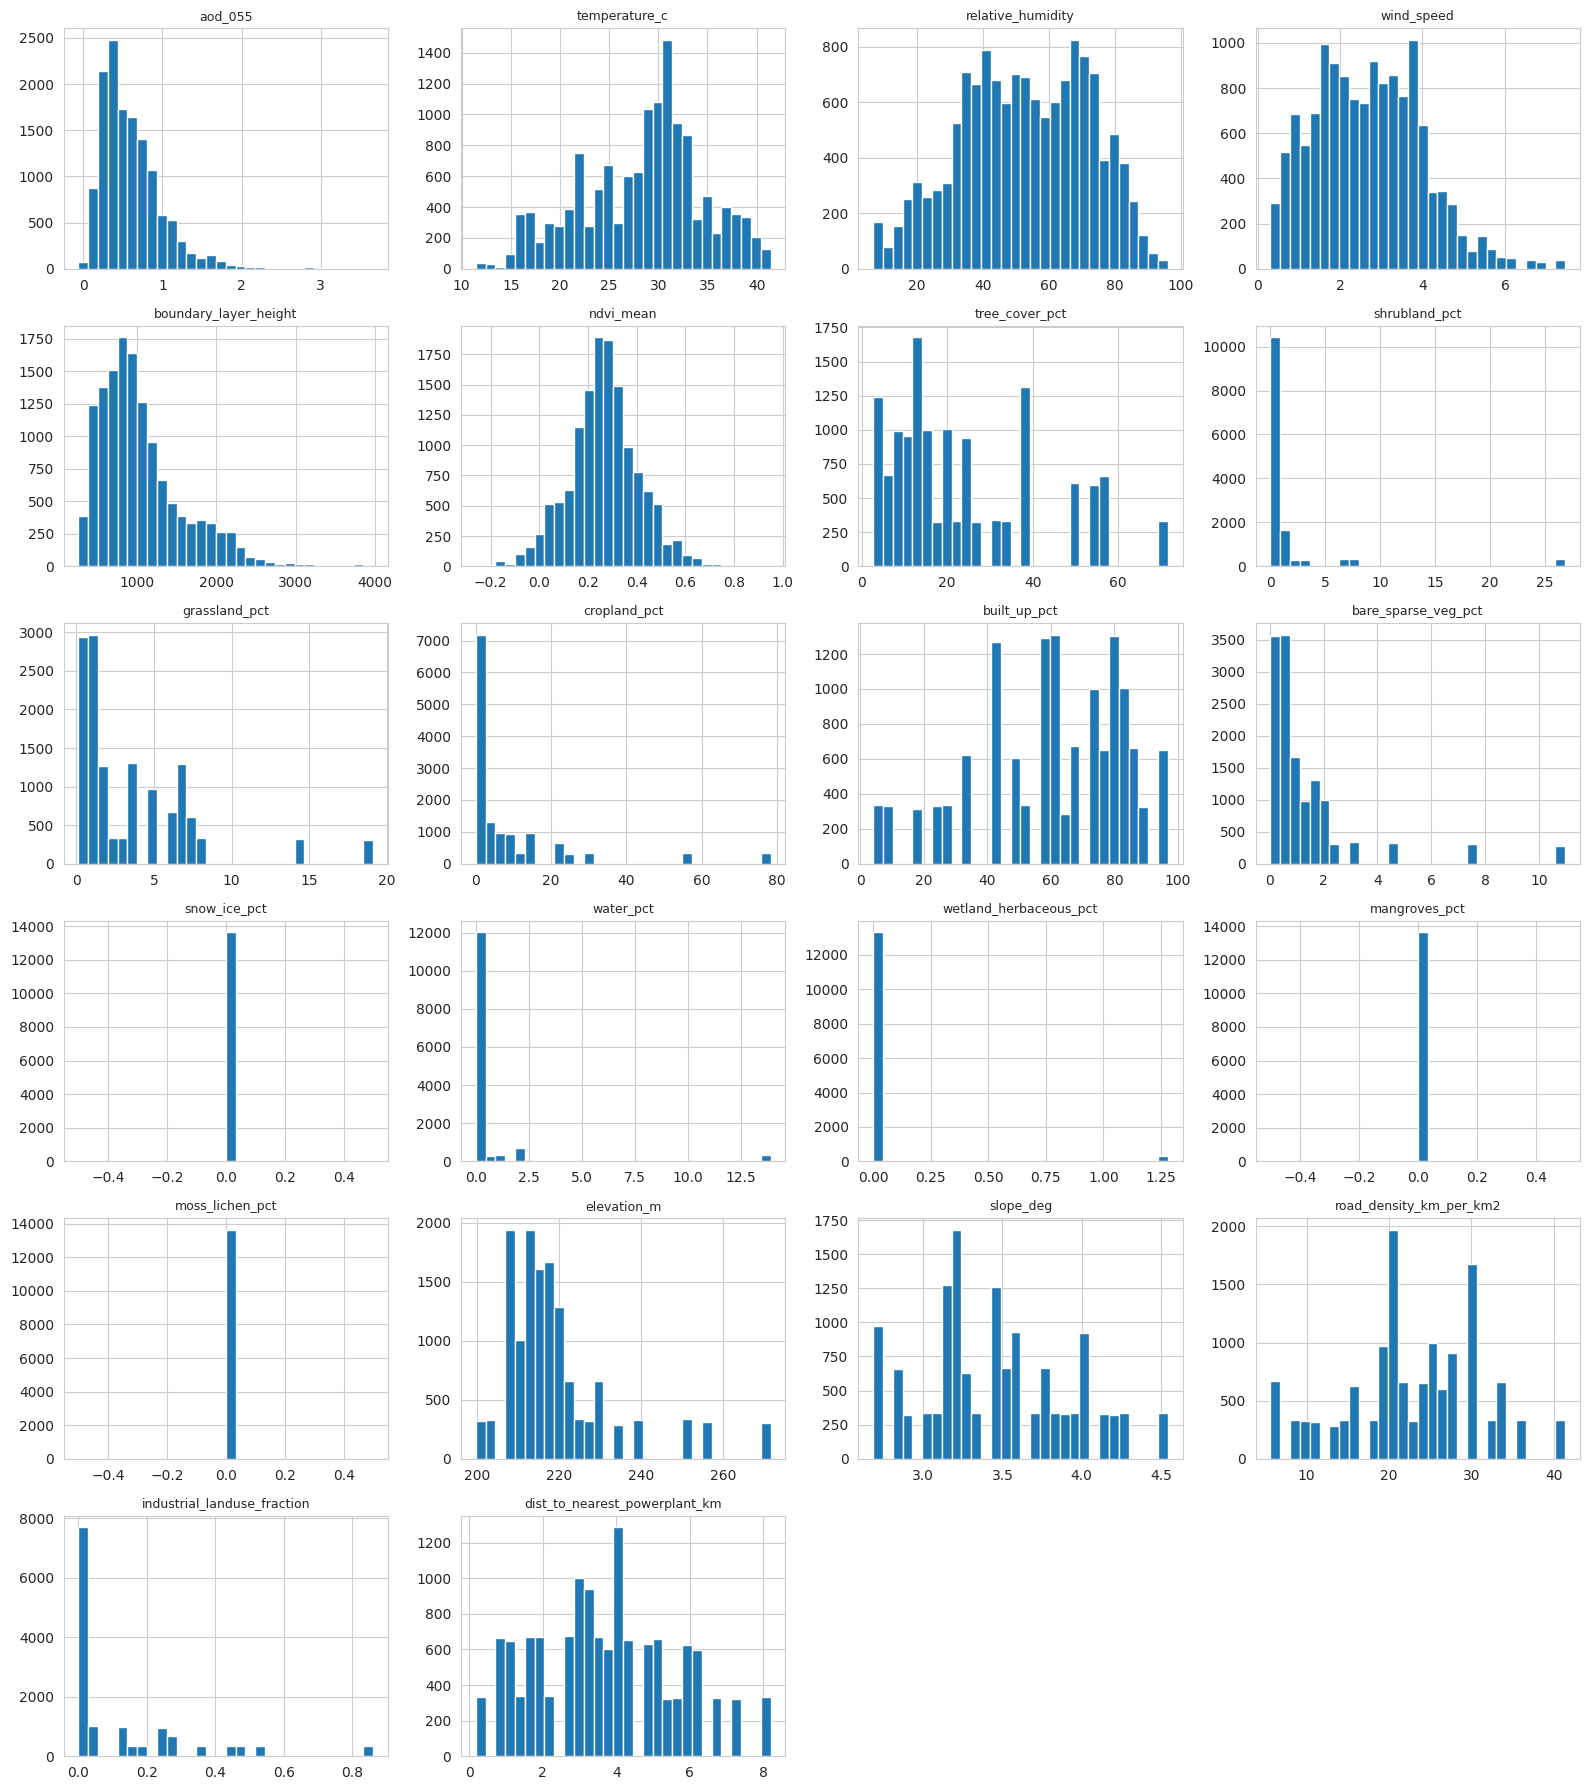

In [11]:
def plot_histograms(data, cols, n_per_row=4):
    n_rows = -(-len(cols) // n_per_row)  # ceil division
    fig, axes = plt.subplots(n_rows, n_per_row, figsize=(4 * n_per_row, 3 * n_rows))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        ax.hist(data[col].dropna(), bins=30)
        ax.set_title(col, fontsize=9)
    for ax in axes[len(cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_histograms(df, NUMERIC_COLS)

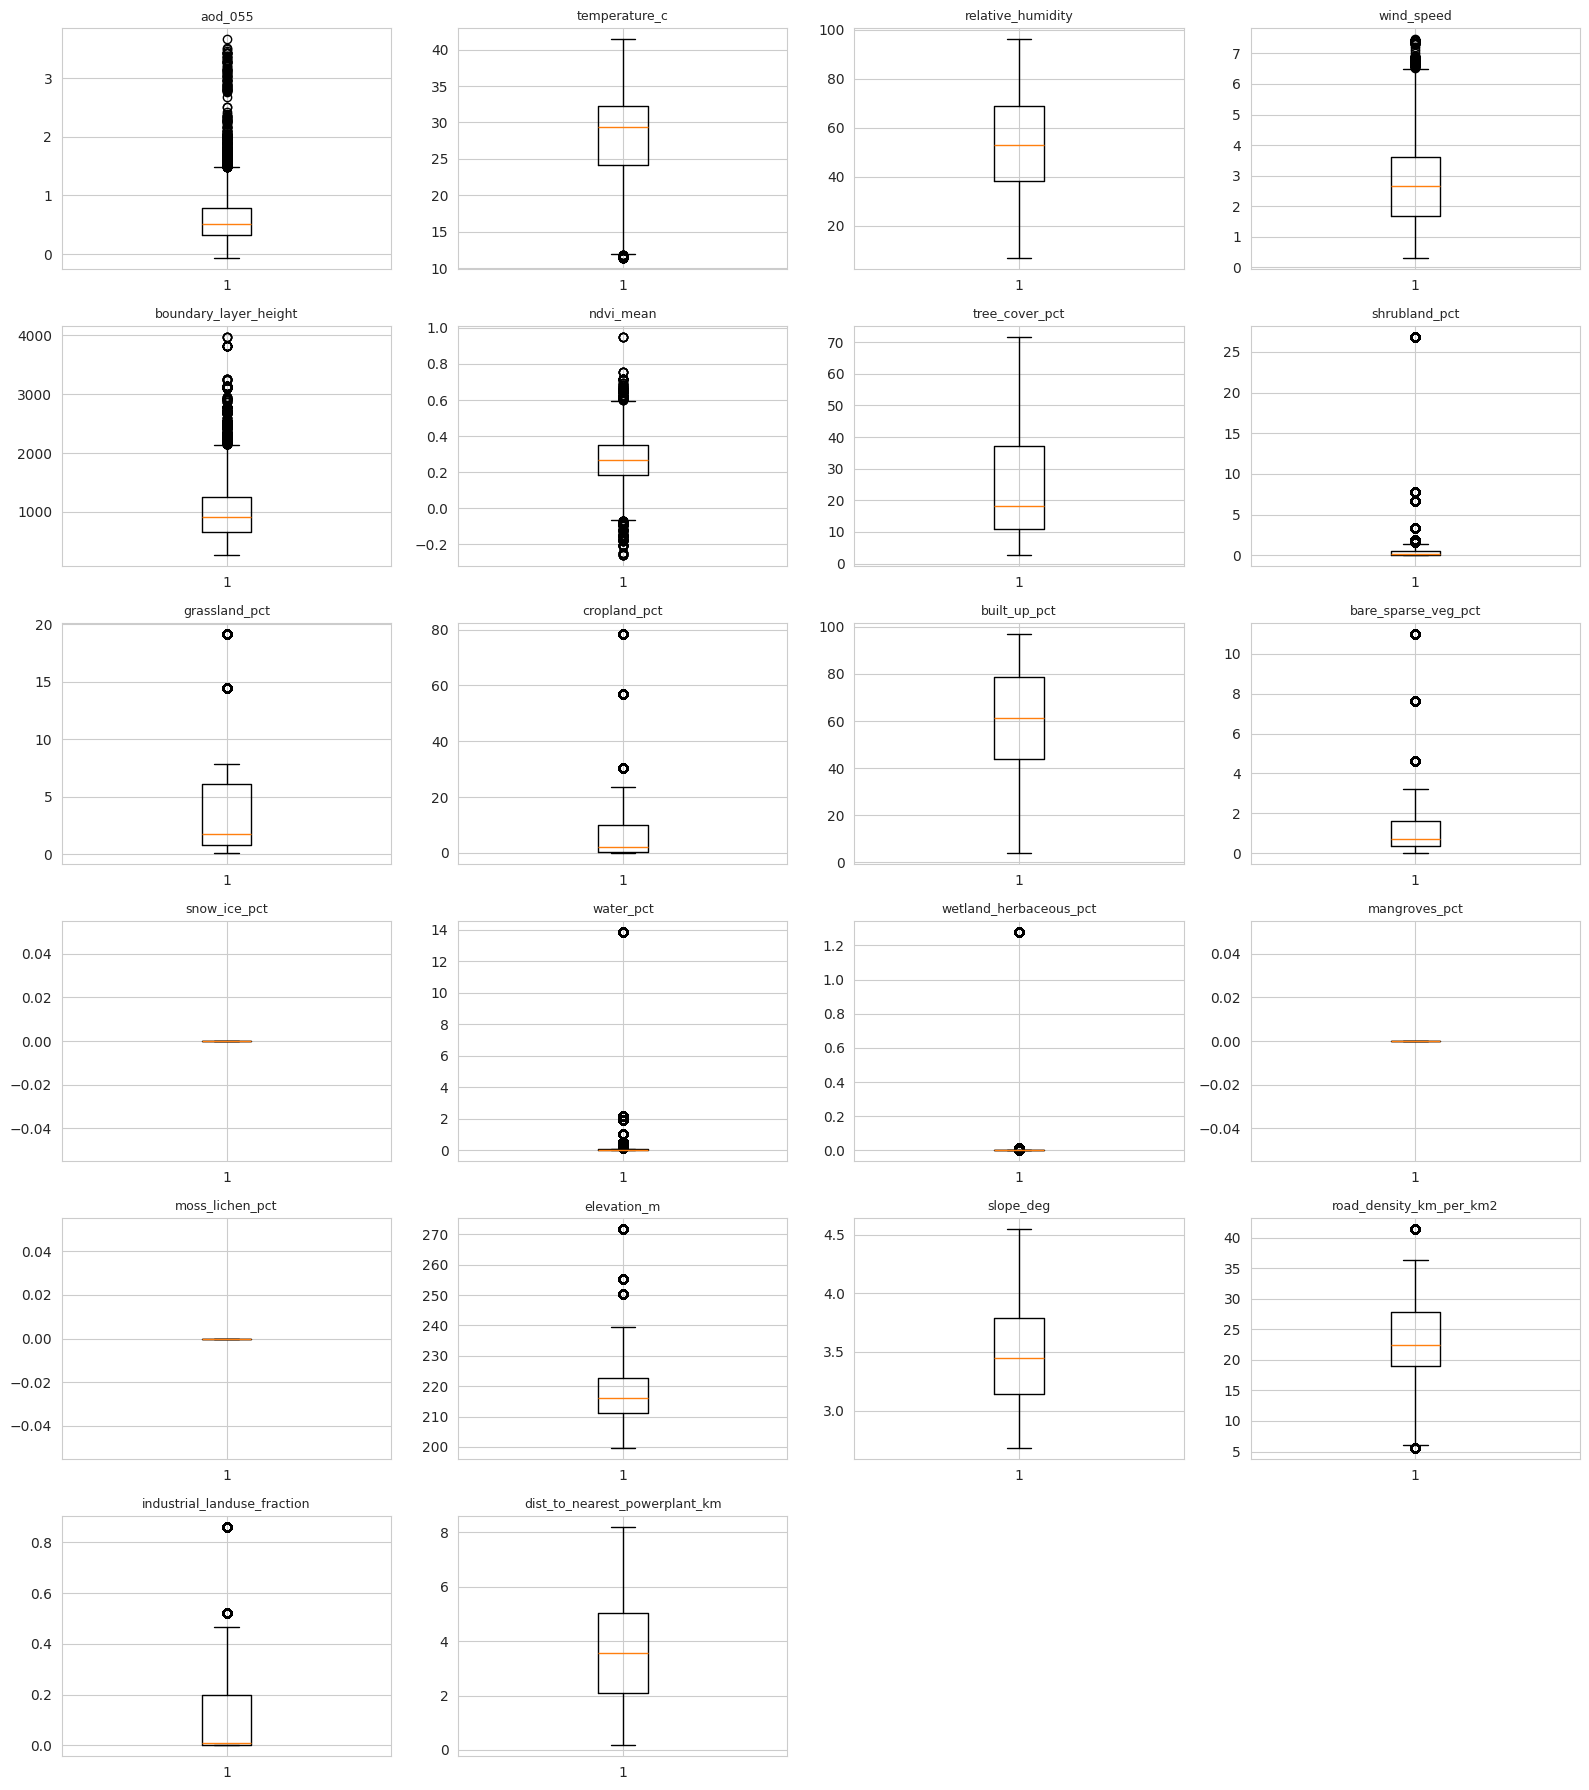

In [12]:
def plot_boxplots(data, cols, n_per_row=4):
    n_rows = -(-len(cols) // n_per_row)
    fig, axes = plt.subplots(n_rows, n_per_row, figsize=(4 * n_per_row, 3 * n_rows))
    axes = axes.flatten()
    for ax, col in zip(axes, cols):
        ax.boxplot(data[col].dropna())
        ax.set_title(col, fontsize=9)
    for ax in axes[len(cols):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_boxplots(df, NUMERIC_COLS)

=== season ===
season
monsoon         4718
summer          3481
winter          3067
post_monsoon    2375
Name: count, dtype: int64


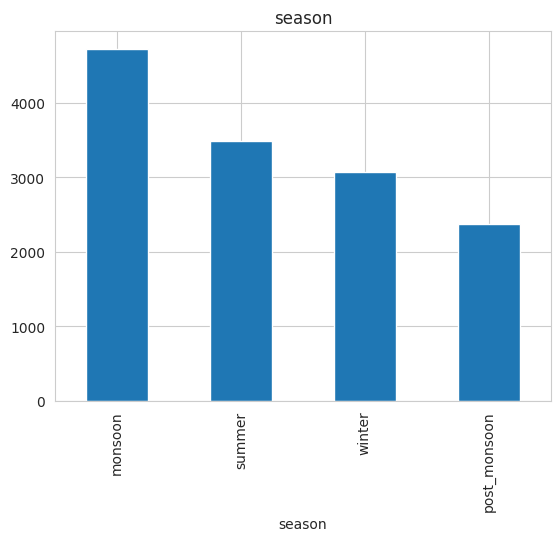

In [13]:
for col in CATEGORICAL_COLS:
    print(f"=== {col} ===")
    print(df[col].value_counts())
    df[col].value_counts().plot(kind="bar", title=col)
    plt.show()

## 4. Target variable, specifically

Same univariate treatment, but focused on the outcome -- its distribution
shape often decides preprocessing choices (e.g. whether a log-transform is
needed before a linear model).

In [14]:
print(df[TARGET_COL].describe())
print(f"Skewness: {df[TARGET_COL].skew():.3f}")
print(f"Kurtosis: {df[TARGET_COL].kurt():.3f}")

stat, p_value = stats.normaltest(df[TARGET_COL].dropna())
print(f"D'Agostino normality test: stat={stat:.1f}, p={p_value:.4g} (p < 0.05 means not normal)")

count    13641.000000
mean        86.605574
std         76.053009
min          0.000000
25%         34.450000
50%         60.325000
75%        113.333333
max        650.000000
Name: pm25_daily, dtype: float64
Skewness: 1.886
Kurtosis: 4.666
D'Agostino normality test: stat=5183.9, p=0 (p < 0.05 means not normal)


Excluding 46 rows with pm25_daily <= 0 from the log-transform view


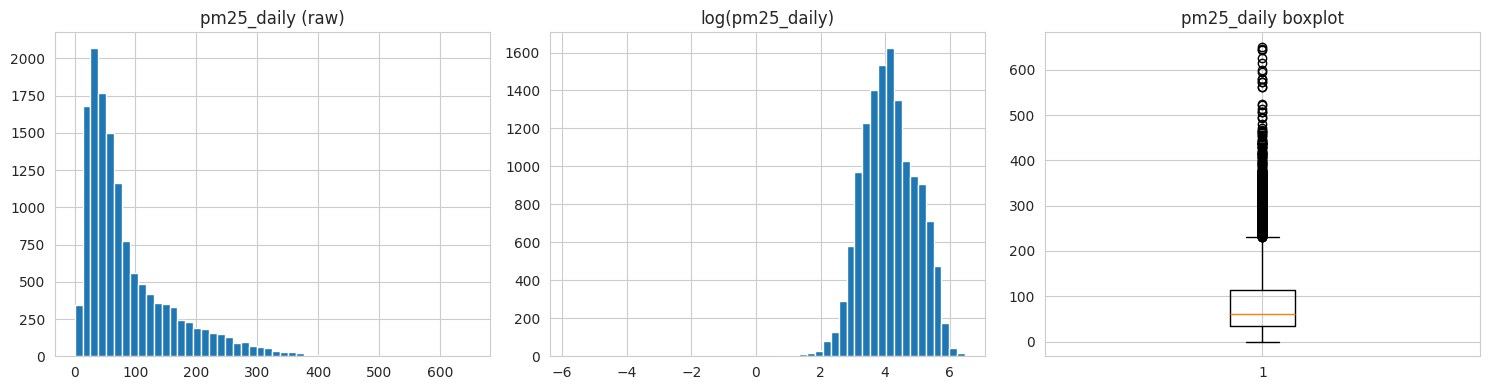

Skew raw: 1.886, skew log: -0.414


In [15]:
# log(0) is -inf, so rows that are exactly 0 (flagged as suspicious in Phase 2)
# have to be excluded from the log view specifically -- not from the raw view
n_zero_or_negative = (df[TARGET_COL] <= 0).sum()
print(f"Excluding {n_zero_or_negative} rows with {TARGET_COL} <= 0 from the log-transform view")
positive_target = df[df[TARGET_COL] > 0][TARGET_COL]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[TARGET_COL].dropna(), bins=50)
axes[0].set_title(f"{TARGET_COL} (raw)")

axes[1].hist(np.log(positive_target), bins=50)
axes[1].set_title(f"log({TARGET_COL})")

axes[2].boxplot(df[TARGET_COL].dropna())
axes[2].set_title(f"{TARGET_COL} boxplot")

plt.tight_layout()
plt.show()

print(f"Skew raw: {df[TARGET_COL].skew():.3f}, skew log: {np.log(positive_target).skew():.3f}")

## 5. Bivariate analysis — predictors vs. target

Which variables actually look related to the outcome, and does the
relationship look linear?

In [16]:
pearson_corr = df[NUMERIC_COLS + [TARGET_COL]].corr(method="pearson")[TARGET_COL].drop(TARGET_COL)
spearman_corr = df[NUMERIC_COLS + [TARGET_COL]].corr(method="spearman")[TARGET_COL].drop(TARGET_COL)

corr_table = pd.DataFrame({"pearson_r": pearson_corr, "spearman_r": spearman_corr})
corr_table["abs_pearson_r"] = corr_table["pearson_r"].abs()
corr_table.sort_values("abs_pearson_r", ascending=False).drop(columns="abs_pearson_r")

,pearson_r,spearman_r
temperature_c,-0.499465,-0.484514
aod_055,0.397936,0.413182
boundary_layer_height,-0.273375,-0.271773
wind_speed,-0.248457,-0.261145
relative_humidity,-0.115225,-0.284210
built_up_pct,0.064681,0.069171
road_density_km_per_km2,0.064262,0.069541
tree_cover_pct,-0.045609,-0.044070
elevation_m,-0.044350,-0.002155
ndvi_mean,0.041313,0.072045


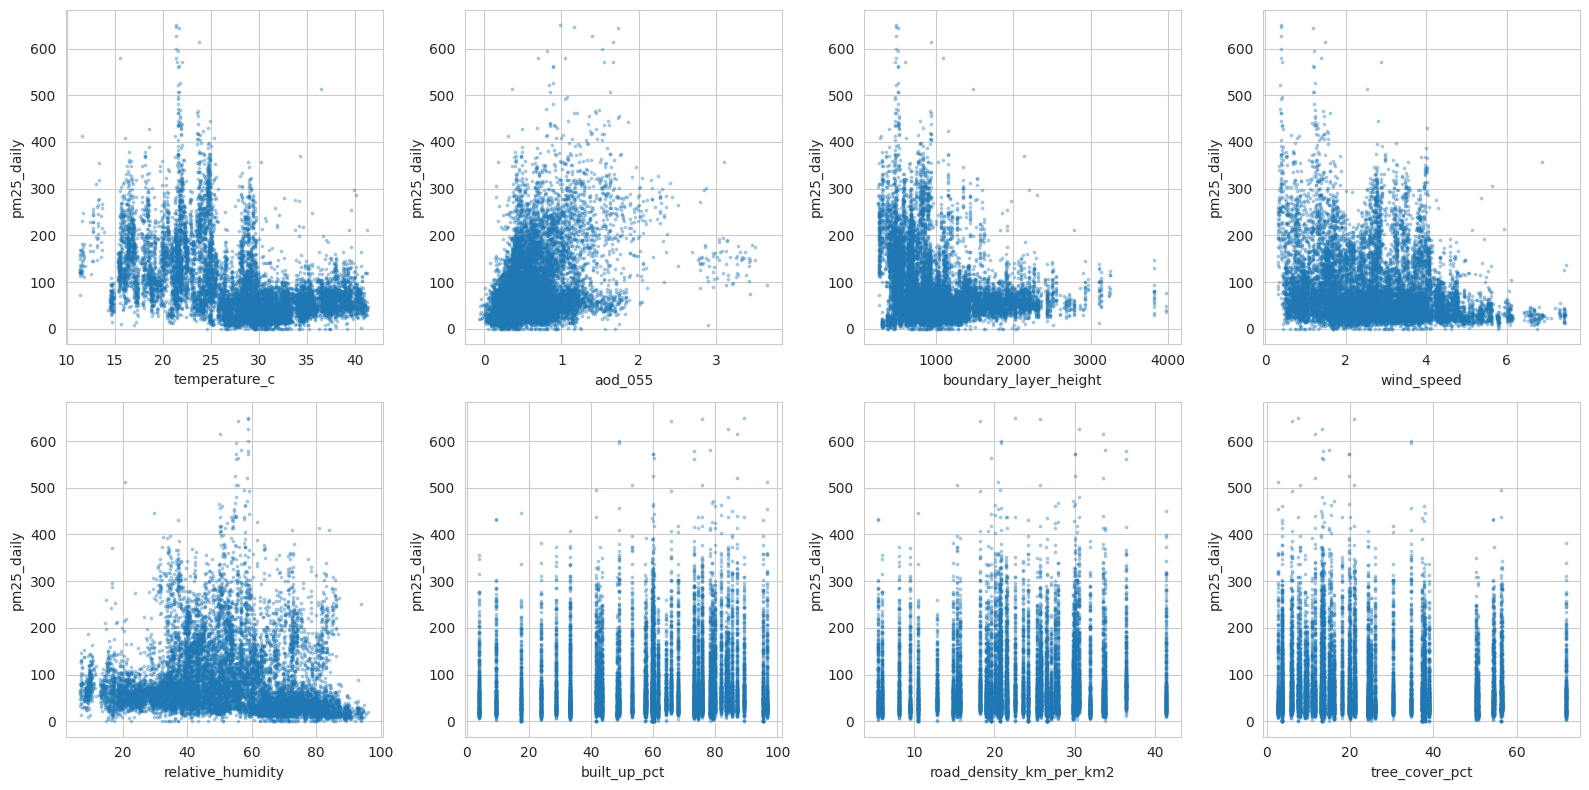

In [17]:
top_predictors = pearson_corr.abs().sort_values(ascending=False).head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, top_predictors):
    ax.scatter(df[col], df[TARGET_COL], s=3, alpha=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

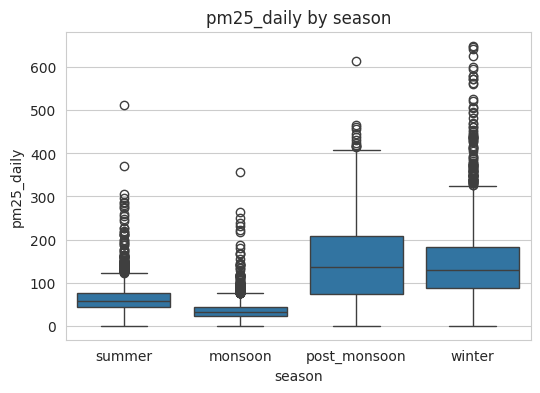

In [18]:
for col in CATEGORICAL_COLS:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=col, y=TARGET_COL)
    plt.title(f"{TARGET_COL} by {col}")
    plt.show()

AOD is the core predictor this whole project is built around -- worth
looking at its relationship with the target broken out by season specifically,
since a season-varying AOD slope is the central modeling hypothesis.

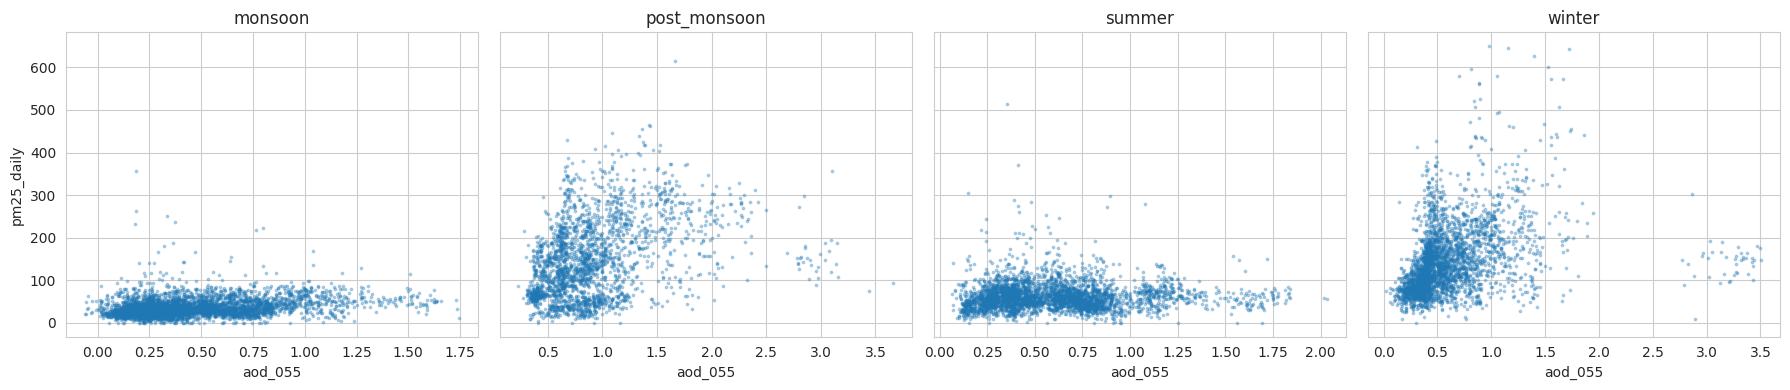

In [19]:
seasons = sorted(df["season"].unique())
fig, axes = plt.subplots(1, len(seasons), figsize=(4.5 * len(seasons), 4), sharey=True)
for ax, season in zip(axes, seasons):
    sub = df[df["season"] == season]
    ax.scatter(sub["aod_055"], sub[TARGET_COL], s=3, alpha=0.3)
    ax.set_title(season)
    ax.set_xlabel("aod_055")
axes[0].set_ylabel(TARGET_COL)
plt.tight_layout()
plt.show()

## 6. Multivariate / correlation structure among predictors

Catching multicollinearity before it becomes a modeling problem.

Note: the 11 WorldCover `_pct` columns sum to a constant 100% by construction
(compositional data) -- expect very large/unstable VIFs involving those
columns below. That's not a bug, it's exactly the diagnostic that motivated
dropping several of them (and using a reference category) in the LME-ready
dataset.

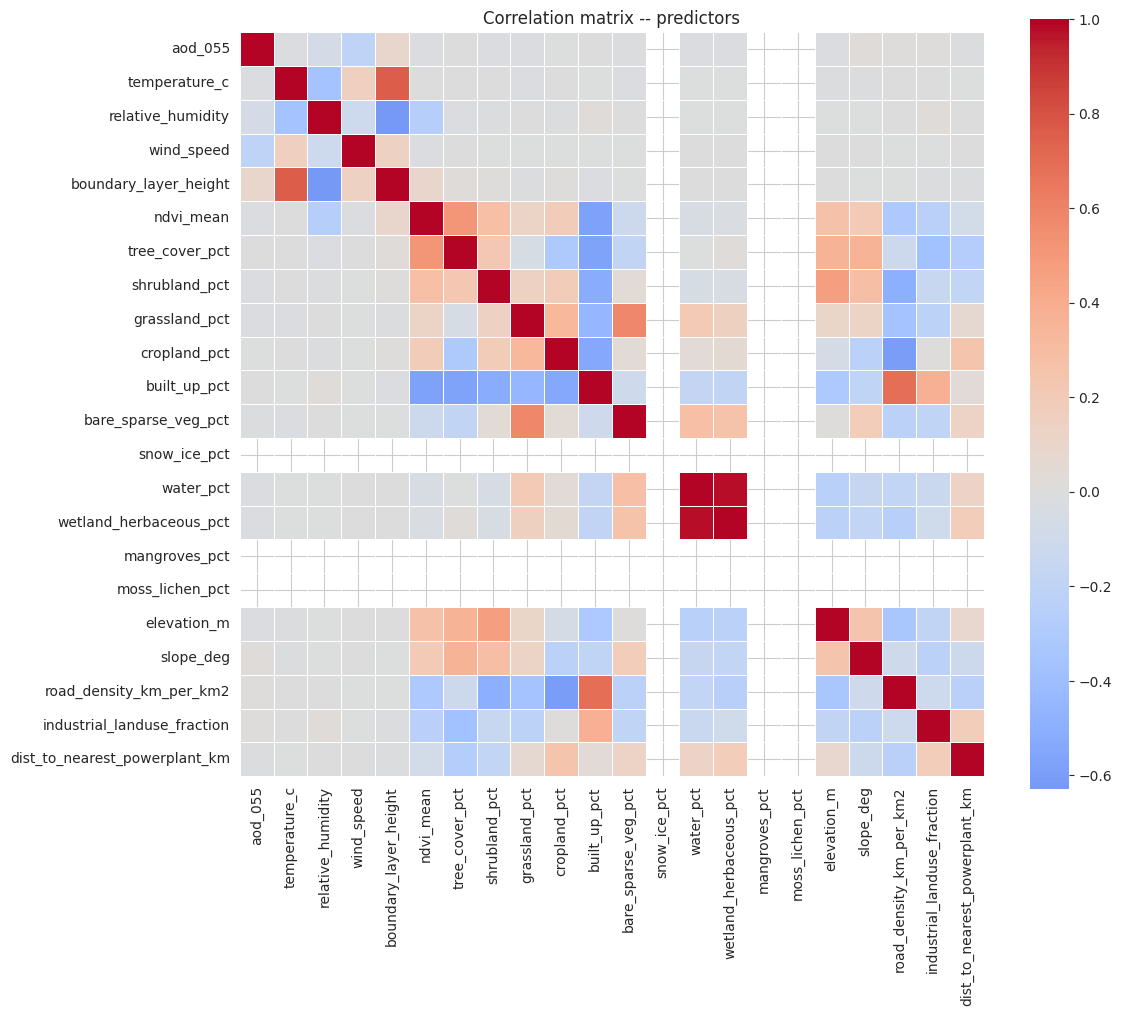

In [20]:
corr_matrix = df[NUMERIC_COLS].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Correlation matrix -- predictors")
plt.show()

In [21]:
# highly correlated pairs (|r| > 0.7), each pair listed once
pairs = corr_matrix.abs().unstack()
pairs = pairs[pairs < 1.0]
pairs = pairs[pairs > 0.7].sort_values(ascending=False)

seen = set()
for (col_a, col_b), r in pairs.items():
    pair_key = tuple(sorted([col_a, col_b]))
    if pair_key in seen:
        continue
    seen.add(pair_key)
    print(f"{col_a} <-> {col_b}: r = {r:.3f}")

wetland_herbaceous_pct <-> water_pct: r = 0.975
boundary_layer_height <-> temperature_c: r = 0.763


In [22]:
vif_df = df[NUMERIC_COLS].dropna()
vif_table = pd.DataFrame({
    "column": NUMERIC_COLS,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(NUMERIC_COLS))],
})
vif_table.sort_values("VIF", ascending=False)

/sessions/rcw-01cus6pxajd18de3yckb6iqv/tmp/ipykernel_9/1717908115.py:4: UserWarning: The design matrix is poorly conditioned (condition number=6.07e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(NUMERIC_COLS))],
/sessions/rcw-01cus6pxajd18de3yckb6iqv/.local/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/sessions/rcw-01cus6pxajd18de3yckb6iqv/.local/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/sessions/rcw-01cus6pxajd18de3yckb6iqv/.local/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank

/sessions/rcw-01cus6pxajd18de3yckb6iqv/.local/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/sessions/rcw-01cus6pxajd18de3yckb6iqv/.local/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


,column,VIF
8,grassland_pct,1.000800e+15
9,cropland_pct,1.000800e+15
6,tree_cover_pct,1.000800e+15
10,built_up_pct,1.000800e+15
14,wetland_herbaceous_pct,1.000800e+15
13,water_pct,1.000800e+15
7,shrubland_pct,1.000800e+15
11,bare_sparse_veg_pct,1.000800e+15
19,road_density_km_per_km2,6.268707e+00
4,boundary_layer_height,3.714183e+00


## 7. Structural checks specific to this data's shape

This is the phase that varies by dataset -- here it's a grouping variable
(station), a time dimension (date), and a spatial dimension (lat/lon).

### 7a. Group structure — does this justify a random intercept per station?

In [23]:
station_stats = df.groupby(GROUP_COL)[TARGET_COL].agg(["mean", "std", "count"]).sort_values("mean")
station_stats

,mean,std,count
location_id,,,
11607,63.245880,55.469162,270
5650,69.432087,46.839818,285
10921,69.883098,62.189009,315
5627,72.097606,60.184680,330
6359,73.799993,57.470791,335
5626,74.191783,78.273567,338
10488,75.010289,64.234963,335
10484,76.348014,65.437928,331
5570,76.411814,53.782247,304


In [24]:
between_station_var = station_stats["mean"].var()
within_station_var = df.groupby(GROUP_COL)[TARGET_COL].var().mean()
icc_like = between_station_var / (between_station_var + within_station_var)

print(f"Between-station variance: {between_station_var:.1f}")
print(f"Average within-station variance: {within_station_var:.1f}")
print(f"Rough ICC (share of variance that's between-station): {icc_like:.3f}")
print("(A higher share means stations differ more from each other than days differ")
print(" within a station -- the more this holds, the more a random intercept is earning its keep.)")

Between-station variance: 130.3
Average within-station variance: 5629.8
Rough ICC (share of variance that's between-station): 0.023
(A higher share means stations differ more from each other than days differ
 within a station -- the more this holds, the more a random intercept is earning its keep.)


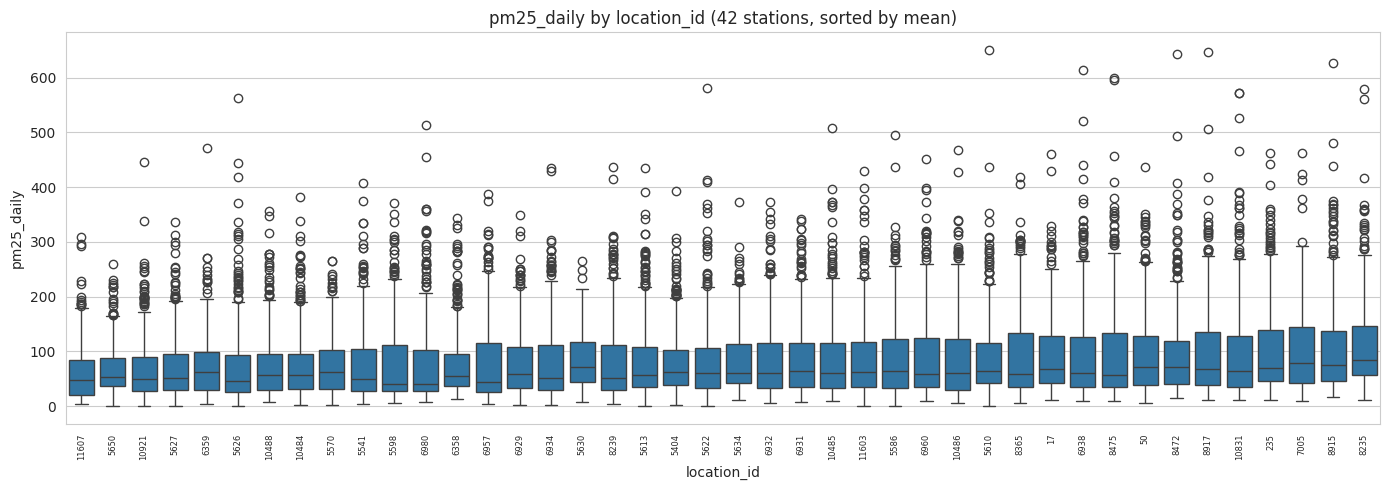

In [25]:
order = station_stats.index.tolist()
plt.figure(figsize=(14, 5))
sns.boxplot(data=df, x=GROUP_COL, y=TARGET_COL, order=order)
plt.xticks(rotation=90, fontsize=6)
plt.title(f"{TARGET_COL} by {GROUP_COL} ({df[GROUP_COL].nunique()} stations, sorted by mean)")
plt.tight_layout()
plt.show()

### 7b. Time dimension — trend and seasonality

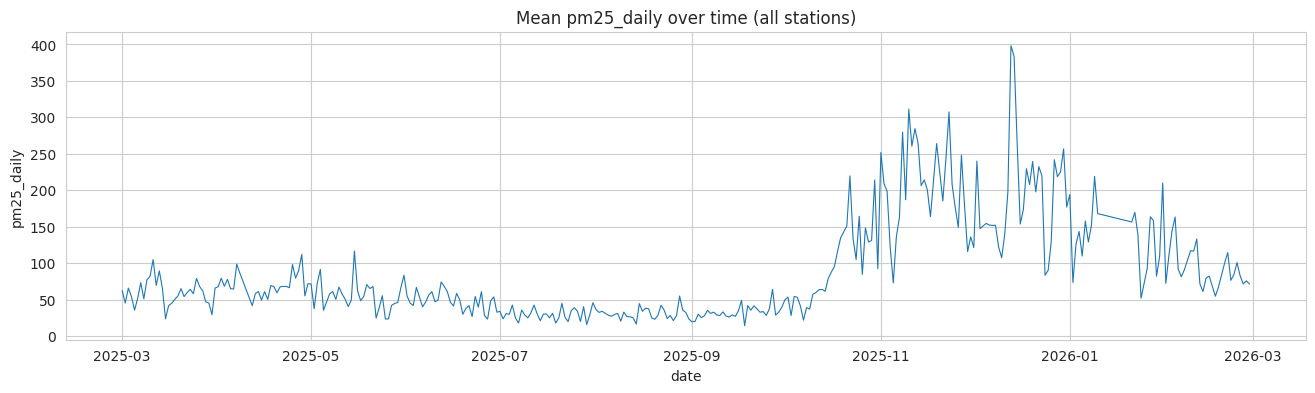

In [26]:
if DATE_COL:
    daily_mean = df.groupby(DATE_COL)[TARGET_COL].mean()
    plt.figure(figsize=(16, 4))
    plt.plot(daily_mean.index, daily_mean.values, linewidth=0.8)
    plt.title(f"Mean {TARGET_COL} over time (all stations)")
    plt.xlabel(DATE_COL)
    plt.ylabel(TARGET_COL)
    plt.show()
else:
    print("No DATE_COL set -- skipping.")

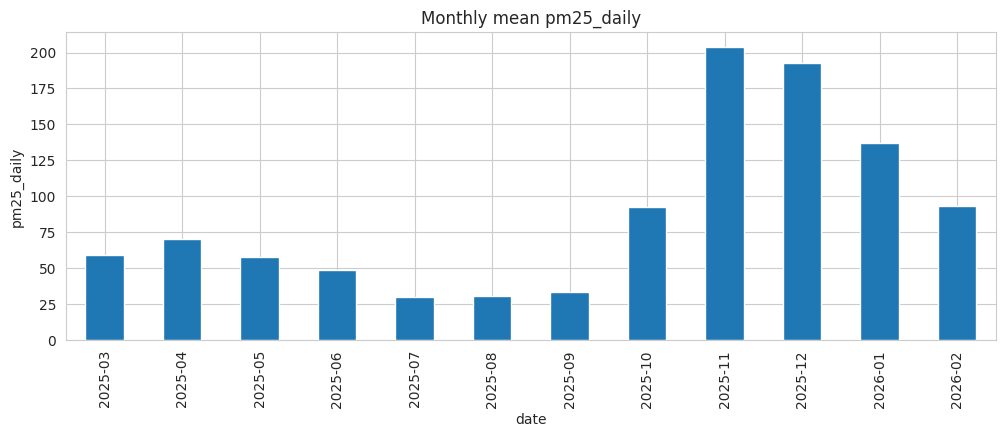

In [27]:
if DATE_COL:
    monthly_mean = df.groupby(df[DATE_COL].dt.to_period("M"))[TARGET_COL].mean()
    monthly_mean.plot(kind="bar", figsize=(12, 4), title=f"Monthly mean {TARGET_COL}")
    plt.ylabel(TARGET_COL)
    plt.show()
else:
    print("No DATE_COL set -- skipping.")

### 7c. Spatial dimension — does location matter?

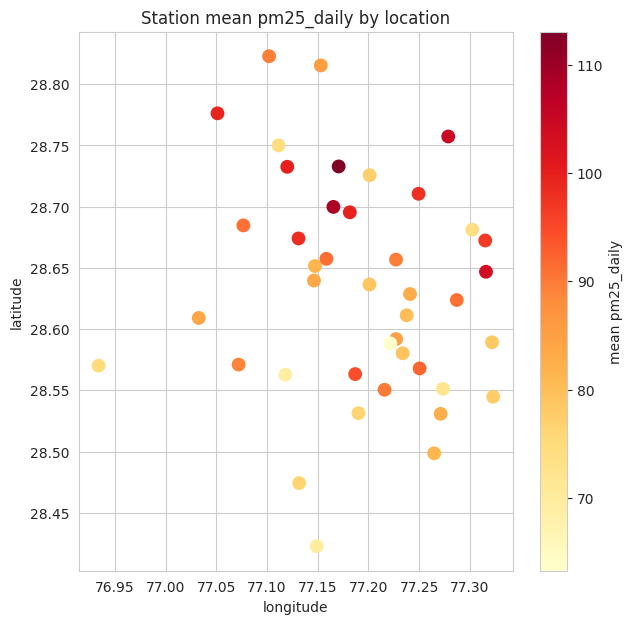

In [28]:
if LAT_COL and LON_COL:
    station_summary = df.groupby(GROUP_COL).agg({TARGET_COL: "mean", LAT_COL: "first", LON_COL: "first"})
    plt.figure(figsize=(7, 7))
    sc = plt.scatter(station_summary[LON_COL], station_summary[LAT_COL],
                      c=station_summary[TARGET_COL], cmap="YlOrRd", s=80)
    plt.colorbar(sc, label=f"mean {TARGET_COL}")
    plt.xlabel("longitude")
    plt.ylabel("latitude")
    plt.title(f"Station mean {TARGET_COL} by location")
    plt.show()
else:
    print("No LAT_COL/LON_COL set -- skipping.")

## 8. Follow-up check — did the LME land-use reduction actually fix VIF?

Phase 6 showed near-infinite VIF for the 11 raw WorldCover columns (the
closure problem). The LME-ready dataset already drops 5 of them (3
always-zero, 1 negligible, `water_pct` as the reference category). Checking
whether that actually fixed it, rather than assuming it did, by rerunning VIF
on the real final design matrix instead of the master table's full column set.

In [29]:
lme_df = pd.read_csv("../data/processed/modeling_datasets/lme_ready_dataset.csv")

lme_check_cols = [
    "aod_055", "temperature_c", "relative_humidity", "wind_speed", "boundary_layer_height",
    "ndvi_mean", "tree_cover_pct", "shrubland_pct", "grassland_pct", "cropland_pct",
    "built_up_pct", "bare_sparse_veg_pct", "elevation_m", "slope_deg",
    "road_density_km_per_km2", "industrial_landuse_fraction", "dist_to_nearest_powerplant_km",
]

lme_vif_table = pd.DataFrame({
    "column": lme_check_cols,
    "VIF": [variance_inflation_factor(lme_df[lme_check_cols].values, i) for i in range(len(lme_check_cols))],
})
lme_vif_table.sort_values("VIF", ascending=False)

,column,VIF
10,built_up_pct,160.240248
6,tree_cover_pct,95.587476
9,cropland_pct,64.910850
7,shrubland_pct,7.839203
8,grassland_pct,6.928794
14,road_density_km_per_km2,5.265815
4,boundary_layer_height,3.711953
11,bare_sparse_veg_pct,3.559643
1,temperature_c,2.590457
15,industrial_landuse_fraction,2.269216


## Summary / notes (2026-09-09)

**Target distribution**
- `pm25_daily` is heavily right-skewed (skew 1.89, kurtosis 4.67); D'Agostino test rejects normality decisively (p ~ 0).
- `log(pm25_daily)` brings skew down to -0.41 -- much closer to symmetric. LME's Gaussian-residual assumption is far better satisfied on the log scale than the raw scale.
- **Open decision, not yet made**: switch the LME target to `log(pm25_daily)`? Changes coefficient interpretation from additive (ug/m3) to multiplicative (% change), so this is a call for the researcher, not an automatic pipeline fix -- but the skew makes a strong case for it.

**Data quality issues found (not caught earlier in the pipeline)**
- 46 station-days with `pm25_daily` exactly 0.0 -- physically implausible for ambient PM2.5, likely sensor artifacts. These also break a log-transform outright (`log(0) = -inf`), so they need to be dropped regardless of the log-transform decision.
- 11 station-days with negative `aod_055` -- all are MERRA2-calibrated gap-fills from Aug 19-21 2025 (monsoon washout), not raw MAIAC readings. The linear calibration model has no positivity constraint, so very clean-air days can dip slightly below zero. Minor (11 rows), but AOD can't physically be negative -- worth clipping to 0.

**Multicollinearity**
- `wetland_herbaceous_pct` <-> `water_pct`, r=0.975 -- both already excluded from the LME feature set, doesn't affect the final model.
- `boundary_layer_height` <-> `temperature_c`, r=0.76 -- both required by the fixed M0 equation, so neither can be dropped; flagged as an interpretation caveat (individual coefficients may be less stable than an uncorrelated pair would give), not a dataset change.
- The 11 raw WorldCover `_pct` columns showed near-infinite VIF in Phase 6 -- confirmed to be the compositional-data "closure problem" (they sum to a constant 100%). Section 8 reruns VIF on the actual final LME design matrix: **the fix only partly worked**. Dropping `water_pct` as reference removed the exact singularity (no more astronomical/infinite values), but three of the remaining six columns are still well above the usual VIF>5-10 danger threshold: `built_up_pct` (160), `tree_cover_pct` (96), `cropland_pct` (65). `shrubland_pct` (7.8) and `grassland_pct` (6.9) are mildly elevated; `bare_sparse_veg_pct` (3.6) is fine. This makes sense -- those three are the dominant land-use categories (together ~93% of the average station's composition), so even with one reference category removed, they still substantially trade off against each other. A single reference-category drop resolves the mathematical singularity but doesn't fully decorrelate dominant compositional categories -- a known limitation of this approach, not a bug in the implementation.

**Station structure**
- Rough ICC (share of variance that's between-station) is low, ~2.3% -- stations differ far less from each other than day-to-day variation within a station. Doesn't invalidate the random intercept, but worth reporting candidly; may look different recomputed on the log scale, since raw PM2.5's extreme right tail likely inflates the within-station variance estimate.

**Recommended changes to the LME-ready dataset (pending confirmation before implementing)**
1. Drop the 46 `pm25_daily == 0` rows -- data-quality exclusion, independent of the log-transform decision.
2. Clip the 11 negative `aod_055` values to 0 before scaling -- fixes a known artifact of the gap-fill model.
3. Decide: fit on `pm25_daily` or `log(pm25_daily)` -- recommended given the skew, but changes coefficient interpretation and is the researcher's call.
4. ~~Re-run VIF restricted to the actual final LME design matrix~~ -- done in Section 8; revealed remaining moderate-to-severe collinearity among `built_up_pct`/`tree_cover_pct`/`cropland_pct` that a single reference-category drop doesn't resolve.
5. **New, open**: decide whether to accept the elevated VIF on those 3 dominant land-use categories as a reported limitation, or pursue a further fix (e.g. combine into fewer, less-correlated groups, or an isometric log-ratio transform -- the standard compositional-data-analysis approach, a bigger methodology change).